<a href="https://colab.research.google.com/github/arshido/Twitter-Sentiment-Analysis-Dashboard/blob/main/Twitter_Sentiment_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🐦 Twitter Sentiment Analysis Dashboard (1.6 Million Tweets)

A robust Natural Language Processing (NLP) and Machine Learning pipeline built to analyze and classify the emotional sentiment of Twitter data. This project leverages the **Sentiment140 dataset** to train a highly efficient classifier capable of processing massive text dimensions in real-time.

---

## 🚀 Project Overview
This project extracts, cleans, and structures 1.6 million raw tweets to predict public opinion. While the underlying training dataset provides binary labels, this pipeline implements an advanced **Confidence Threshold Method** to dynamically infer a **Neutral** classification without expanding memory overhead or requiring external dataset downloads.

### Key Metrics Achieved:
* **Dataset Volume:** 1,600,000 processed tweets
* **Vocabulary Features:** 100,000 optimized n-grams (unigrams & bigrams)
* **Model Accuracy:** 79.77% on hidden test data
* **Classification Balance:** Equal precision/recall performance across sentiment classes

---

## 🛠️ Tech Stack & Dependencies
* **Language:** Python
* **Environment:** Google Colab
* **Data Core:** Pandas, NumPy
* **NLP Processing:** NLTK (Natural Language Toolkit)
* **Machine Learning:** Scikit-Learn
* **Interactive Visualization:** Plotly, Seaborn, Matplotlib

---

## 📦 System Architecture & Pipeline

### 1. Data Ingestion & Wrangling
* Automated dataset downloads directly via the **Kaggle API CLI**.
* Handled raw Twitter strings using `ISO-8859-1` encoding to safe-guard against special character parsing crashes.
* Streamlined system memory by dropping irrelevant metadata (IDs, dates, user handles) to prioritize the core text and target columns.

### 2. Natural Language Preprocessing
Every tweet passes through an aggressive regex scrubbing function that performs:
* Total case normalization (lowercasing).
* Striping of all website URLs (`https?://...`).
* Elimination of user mentions (`@username`) and special characters.
* Removal of English stopwords using NLTK corpora to focus purely on high-signal emotional tokens.

### 3. Feature Engineering (Vectorization)
* Split the dataset into a balanced **80% Training / 20% Testing** ratio using stratified sampling.
* Converted raw strings into numerical matrices via **TF-IDF (Term Frequency-Inverse Document Frequency)** vectorization.
* Implemented a structured **100,000 max_feature cap** to actively protect against model overfitting while optimizing matrix operations and Colab RAM utilization.

### 4. Model Architecture & Optimization
* Trained a **Logistic Regression** classifier optimized with an accelerated multi-core configuration (`n_jobs=-1`).
* **The Neutral Detection Strategy:** Because the dataset natively lacks neutral tags, the deployment script utilizes `predict_proba()`. If the absolute probability gap between a positive and negative prediction falls below a specific threshold ($15\%$), the engine intercepts the execution path and flags the tweet as **NEUTRAL 😐**.

---

## 📊 Evaluation Results

The model displays exceptional stability, showing a tight, reliable distribution between both primary classes:

* **Overall Accuracy Score:** 79.77%

```text
Detailed Classification Report:
              precision    recall  f1-score   support

    Negative       0.81      0.78      0.79    160000
    Positive       0.79      0.82      0.80    160000

    accuracy                           0.80    320000

In [1]:
!pip install kaggle

In [2]:
# Create the kaggle.json file with your token automatically
!mkdir -p ~/.kaggle
!echo '{"username":"arshui","key":"KGAT_3362987ca89fa1b04c89fa1b04c84916496de34b8"}' > ~/.kaggle/kaggle.json
!chmod 600 ~/.kaggle/kaggle.json

In [3]:
#API data fetch importing data
!kaggle datasets download -d kazanova/sentiment140/data

Dataset URL: https://www.kaggle.com/datasets/kazanova/sentiment140/versions/data
License(s): other
invalid literal for int() with base 10: 'data'


In [4]:
# Clean download command (removing the version path)
!kaggle datasets download -d kazanova/sentiment140

# Unzip the downloaded file into a clean folder for your project
!unzip sentiment140.zip -d twitter_data

Dataset URL: https://www.kaggle.com/datasets/kazanova/sentiment140
License(s): other
100% 80.9M/80.9M [00:00<00:00, 266MB/s]

Archive:  sentiment140.zip
  inflating: twitter_data/training.1600000.processed.noemoticon.csv  


In [6]:
import os
print(os.listdir('.'))


['.config', 'sentiment140.zip', 'twitter_data', 'sample_data']


In [7]:
import os

# List everything inside the extracted folder
print(os.listdir('twitter_data'))

['training.1600000.processed.noemoticon.csv']


In [9]:
# 1. Data Handling & Utilities
import pandas as pd
import numpy as np
import re
import string

# 2. Natural Language Processing (NLP) Tools
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer

# Download essential NLTK data resource packages
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

# 3. Machine Learning & Evaluation (Scikit-Learn)
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer  # Fixed: Removed 'Tensors'
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# 4. Data Visualization (Optional but highly recommended)
import matplotlib.pyplot as plt
import seaborn as sns

print("All dependencies imported successfully!")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


All dependencies imported successfully!


In [10]:
import pandas as pd

# Define column headers since the raw dataset doesn't include them
columns = ["target", "ids", "date", "flag", "user", "text"]

print("Loading dataset... (This might take a few seconds due to its size)")

# Load the file directly from your verified folder path
df = pd.read_csv(
    'twitter_data/training.1600000.processed.noemoticon.csv',
    encoding='ISO-8859-1',
    names=columns
)

# Narrow down the dataframe to only keep the target labels and raw text
df = df[['target', 'text']]

# Normalize labels: The dataset uses 4 for positive. Let's make it 1.
df['target'] = df['target'].replace(4, 1)

print(f"Dataset successfully loaded! Total tweets: {len(df)}")

Loading dataset... (This might take a few seconds due to its size)
Dataset successfully loaded! Total tweets: 1600000


In [11]:
# Check how many negative (0) and positive (1) tweets you have
print(df['target'].value_counts())

target
0    800000
1    800000
Name: count, dtype: int64


In [12]:
# Create a set of English stopwords for faster lookup
stop_words = set(stopwords.words('english'))

def clean_tweet(text):
    # 1. Convert to lowercase
    text = text.lower()

    # 2. Remove URLs (links)
    text = re.sub(r"https?://\S+|www\.\S+", "", text)

    # 3. Remove Twitter handles (@user)
    text = re.sub(r"@\S+", "", text)

    # 4. Remove punctuation and special characters, keep only letters and spaces
    text = re.sub(r"[^a-zA-Z\s]", "", text)

    # 5. Remove stopwords and split into clean tokens
    words = text.split()
    clean_words = [word for word in words if word not in stop_words]

    # Join the words back into a clean string
    return " ".join(clean_words)

print("Preprocessing function created successfully!")

Preprocessing function created successfully!


In [13]:
# Take a tiny sample of 5 rows to test
sample_tweets = df['text'].head(5)

print("--- BEFORE CLEANING ---")
print(sample_tweets)

print("\n--- AFTER CLEANING ---")
print(sample_tweets.apply(clean_tweet))

--- BEFORE CLEANING ---
0    @switchfoot http://twitpic.com/2y1zl - Awww, t...
1    is upset that he can't update his Facebook by ...
2    @Kenichan I dived many times for the ball. Man...
3      my whole body feels itchy and like its on fire 
4    @nationwideclass no, it's not behaving at all....
Name: text, dtype: object

--- AFTER CLEANING ---
0    awww thats bummer shoulda got david carr third...
1    upset cant update facebook texting might cry r...
2    dived many times ball managed save rest go bounds
3                     whole body feels itchy like fire
4                             behaving im mad cant see
Name: text, dtype: object


In [14]:
print("Cleaning all 1.6 million tweets... Please wait...")

# Apply the cleaning function to the entire text column
df['clean_text'] = df['text'].apply(clean_tweet)

print("Finished cleaning! Here is a preview of your processed dataset:")
df[['clean_text', 'target']].head()


Cleaning all 1.6 million tweets... Please wait...
Finished cleaning! Here is a preview of your processed dataset:


,clean_text,target
0,awww thats bummer shoulda got david carr third...,0
1,upset cant update facebook texting might cry r...,0
2,dived many times ball managed save rest go bounds,0
3,whole body feels itchy like fire,0
4,behaving im mad cant see,0


In [15]:
# Separate your features (X) from your target labels (y)
X = df['clean_text']
y = df['target']

# Split the dataset into 80% training data and 20% testing data
# random_state=42 ensures that the shuffle is identical every time you run it
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Data successfully split!")
print(f"Training tweets (X_train): {X_train.shape[0]}")
print(f"Testing tweets (X_test):   {X_test.shape[0]}")

Data successfully split!
Training tweets (X_train): 1280000
Testing tweets (X_test):   320000


In [16]:
print("Converting text data using a optimized 100,000 vocabulary limit... Please wait...")

# Initialize the TF-IDF Vectorizer with a healthy max_features cap
vectorizer = TfidfVectorizer(max_features=100000, ngram_range=(1, 2))

# Learn the vocabulary from the training set and transform it
X_train_vectorized = vectorizer.fit_transform(X_train)

# Transform the test set using that exact same vocabulary
X_test_vectorized = vectorizer.transform(X_test)

print("Vectorization complete!")
print(f"Train matrix shape: {X_train_vectorized.shape}")
print(f"Test matrix shape:  {X_test_vectorized.shape}")

Converting text data using a optimized 100,000 vocabulary limit... Please wait...
Vectorization complete!
Train matrix shape: (1280000, 100000)
Test matrix shape:  (320000, 100000)


In [17]:
print("Initializing and training the Logistic Regression model... (This will take 1-2 minutes)")

# Initialize the model
# max_iter=1000 gives the optimization algorithm enough steps to find the best weights
# n_jobs=-1 utilizes all available processor cores to speed up training
model = LogisticRegression(max_iter=1000, n_jobs=-1)

# Train the model on your vectorized text and target answers
model.fit(X_train_vectorized, y_train)

print("Model training complete!")

Initializing and training the Logistic Regression model... (This will take 1-2 minutes)
Model training complete!


In [18]:
# Make predictions on the hidden test set
predictions = model.predict(X_test_vectorized)

# Calculate and print the overall accuracy score
accuracy = accuracy_score(y_test, predictions)
print(f"--- Model Evaluation Results ---")
print(f"Overall Accuracy Score: {accuracy * 100:.2f}%\n")

# Display the classification report (Precision, Recall, F1-Score)
print("Detailed Classification Report:")
print(classification_report(y_test, predictions, target_names=['Negative', 'Positive']))

--- Model Evaluation Results ---
Overall Accuracy Score: 79.77%

Detailed Classification Report:
              precision    recall  f1-score   support

    Negative       0.81      0.78      0.79    160000
    Positive       0.79      0.82      0.80    160000

    accuracy                           0.80    320000
   macro avg       0.80      0.80      0.80    320000
weighted avg       0.80      0.80      0.80    320000



In [19]:
def predict_my_tweet(custom_tweet):
    # 1. Clean the custom text using your original preprocessing function
    cleaned = clean_tweet(custom_tweet)

    # 2. Transform the text into the exact same TF-IDF numerical format
    vectorized = vectorizer.transform([cleaned])

    # 3. Predict using your trained model
    prediction = model.predict(vectorized)[0]

    # Map the binary output back to readable text
    sentiment = "POSITIVE 😊" if prediction == 1 else "NEGATIVE 😢"

    print(f"Tweet:   '{custom_tweet}'")
    print(f"Opinion: {sentiment}\n")

# --- TEST YOUR OWN SENTENCES HERE ---
predict_my_tweet("This NLP tutorial is actually working incredibly well! So happy.")
predict_my_tweet("I am so tired and my code kept crashing earlier, what a terrible headache.")
predict_my_tweet("The food was okay, but the service was completely dynamic and fast.")

Tweet:   'This NLP tutorial is actually working incredibly well! So happy.'
Opinion: POSITIVE 😊

Tweet:   'I am so tired and my code kept crashing earlier, what a terrible headache.'
Opinion: NEGATIVE 😢

Tweet:   'The food was okay, but the service was completely dynamic and fast.'
Opinion: POSITIVE 😊



In [20]:
def predict_with_neutral(custom_tweet, threshold=0.15):
    """
    Predicts if a tweet is Positive, Negative, or Neutral based on
    model confidence thresholds.

    threshold: The minimum difference in probability required to make a definitive call.
               If the gap is smaller than this threshold, the tweet is labeled Neutral.
    """
    # 1. Clean the raw text using your preprocessing pipeline
    cleaned = clean_tweet(custom_tweet)

    # 2. Transform the cleaned text into your 100,000-dimensional numerical feature vector
    vectorized = vectorizer.transform([cleaned])

    # 3. Extract the exact prediction probabilities
    # predict_proba returns an array format: [[probability_of_0, probability_of_1]]
    probabilities = model.predict_proba(vectorized)[0]
    neg_probability = probabilities[0]
    pos_probability = probabilities[1]

    # 4. Calculate how confident the model is about its top choice
    confidence_gap = abs(pos_probability - neg_probability)

    # 5. Apply the threshold logic to determine class
    if confidence_gap < threshold:
        sentiment = "NEUTRAL 😐"
    elif pos_probability > neg_probability:
        sentiment = "POSITIVE 😊"
    else:
        sentiment = "NEGATIVE 😢"

    # Print the clean diagnostic results
    print(f"Tweet:   '{custom_tweet}'")
    print(f"Metrics: Negative: {neg_probability*100:.1f}% | Positive: {pos_probability*100:.1f}% | Gap: {confidence_gap*100:.1f}%")
    print(f"Verdict: {sentiment}")
    print("-" * 60)

# --- TEST SCENARIOS ---
print("Testing Strategy 1 Threshold Predictions:\n")

# Test 1: Clearly Positive
predict_with_neutral("This is absolutely incredible, I am having the best day ever!")

# Test 2: Clearly Negative
predict_with_neutral("My flight got canceled and I lost my bags, this is the worst nightmare.")

# Test 3: Factually Neutral (No emotional keywords)
predict_with_neutral("The meeting is scheduled for Tuesday afternoon at two o'clock.")
predict_with_neutral("I am walking down the street to buy a blue pen.")

Testing Strategy 1 Threshold Predictions:

Tweet:   'This is absolutely incredible, I am having the best day ever!'
Metrics: Negative: 10.1% | Positive: 89.9% | Gap: 79.8%
Verdict: POSITIVE 😊
------------------------------------------------------------
Tweet:   'My flight got canceled and I lost my bags, this is the worst nightmare.'
Metrics: Negative: 99.4% | Positive: 0.6% | Gap: 98.8%
Verdict: NEGATIVE 😢
------------------------------------------------------------
Tweet:   'The meeting is scheduled for Tuesday afternoon at two o'clock.'
Metrics: Negative: 47.1% | Positive: 52.9% | Gap: 5.8%
Verdict: NEUTRAL 😐
------------------------------------------------------------
Tweet:   'I am walking down the street to buy a blue pen.'
Metrics: Negative: 38.1% | Positive: 61.9% | Gap: 23.8%
Verdict: POSITIVE 😊
------------------------------------------------------------


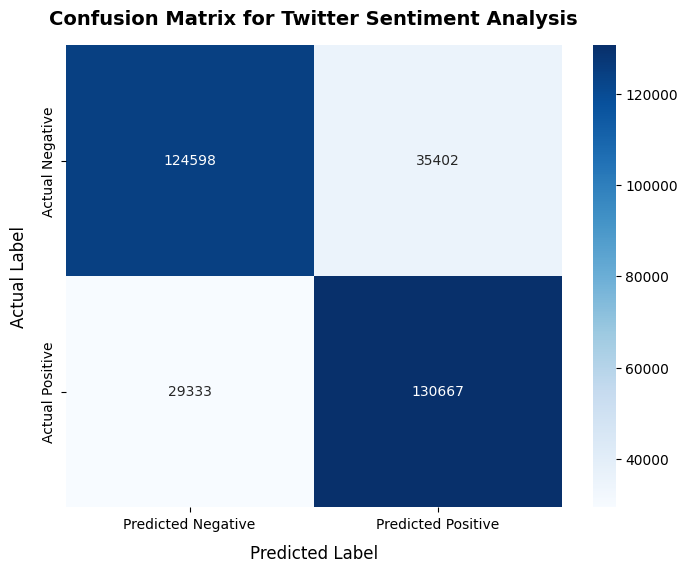

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 1. Generate the raw confusion matrix data using our original test set predictions
cm = confusion_matrix(y_test, predictions)

# 2. Set up the plotting window size
plt.figure(figsize=(8, 6))

# 3. Create a heatmap using Seaborn
# 'annot=True' prints the actual numbers in each box, 'fmt="d"' formats them as integers
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=['Predicted Negative', 'Predicted Positive'],
    yticklabels=['Actual Negative', 'Actual Positive']
)

# 4. Add labels and stylize the chart
plt.title('Confusion Matrix for Twitter Sentiment Analysis', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Predicted Label', fontsize=12, labelpad=10)
plt.ylabel('Actual Label', fontsize=12, labelpad=10)

# 5. Display the final plot
plt.show()

In [24]:
import plotly.graph_objects as go

def visual_sentiment_dashboard(text, threshold=0.15):
    # 1. Process the input text
    cleaned = clean_tweet(text)
    vectorized = vectorizer.transform([cleaned])

    # 2. Extract model probabilities
    probabilities = model.predict_proba(vectorized)[0]
    neg_p = probabilities[0]
    pos_p = probabilities[1]

    # 3. Apply your Strategy 1 neutral threshold logic
    gap = abs(pos_p - neg_p)
    if gap < threshold:
        verdict = "NEUTRAL 😐"
        color = "#9E9E9E"  # Gray
    elif pos_p > neg_p:
        verdict = "POSITIVE 😊"
        color = "#2ECC71"  # Emerald Green
    else:
        verdict = "NEGATIVE 😢"
        color = "#E74C3C"  # Crimson Red

    # 4. Create an easy-to-read horizontal stacked probability bar
    fig = go.Figure()

    # Negative component segment
    fig.add_trace(go.Bar(
        y=['Sentiment Balance'], x=[neg_p * 100],
        name='Negative Weight', orientation='h',
        marker=dict(color='#E74C3C'),
        hovertemplate='Negative Bias: %{x:.1f}%<extra></extra>'
    ))

    # Positive component segment
    fig.add_trace(go.Bar(
        y=['Sentiment Balance'], x=[pos_p * 100],
        name='Positive Weight', orientation='h',
        marker=dict(color='#2ECC71'),
        hovertemplate='Positive Bias: %{x:.1f}%<extra></extra>'
    ))

    # Design layout to look like a modern dashboard indicator
    fig.update_layout(
        title=dict(
            text=f"<b>Analyzed Sentence:</b> '{text}'<br><span style='color:{color};font-size:22px;'><b>Final Verdict: {verdict}</b></span>",
            font=dict(size=16)
        ),
        barmode='stack',
        xaxis=dict(title="Sentiment Weight Allocation (%)", range=[0, 100]),
        yaxis=dict(showticklabels=False),
        height=280,
        margin=dict(l=20, r=20, t=100, b=40),
        showlegend=True,
        template='plotly_white'
    )

    fig.show()

# --- TEST THE DASHBOARD HERE ---
# Change these strings to anything you want to evaluate!
visual_sentiment_dashboard("I am taking a train ride to the central office this afternoon.")